Imports


In [2]:
import McsPy

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

import os
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# MCS PyData tools
import McsPy
import McsPy.McsData
from McsPy import ureg, Q_

# VISUALIZATION TOOLS
import matplotlib.pyplot as plt
%matplotlib inline

# SUPRESS WARNINGS
import warnings
warnings.filterwarnings('ignore')

# autoreload modules
%load_ext autoreload
%autoreload 2

# import bombcell module
#import bombcell as bc

In [4]:
import sys
from pathlib import Path
from pprint import pprint 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from modules.filters import lowpass_filter, bandpass_filter

Functions

In [6]:
def plot_analog_stream_channel(analog_stream, channel_idx, from_in_s=0, to_in_s=None, show=True):
    """
    Plots data from a single AnalogStream channel
    
    :param analog_stream: A AnalogStream object
    :param channel_idx: A scalar channel index (0 <= channel_idx < # channels in the AnalogStream)
    :param from_in_s: The start timestamp of the plot (0 <= from_in_s < to_in_s). Default: 0
    :param to_in_s: The end timestamp of the plot (from_in_s < to_in_s <= duration). Default: None (= recording duration)
    :param show: If True (default), the plot is directly created. For further plotting, use show=False
    """
    # extract basic information
    ids = [c.channel_id for c in analog_stream.channel_infos.values()]
    channel_id = ids[channel_idx]
    channel_info = analog_stream.channel_infos[channel_id]
    sampling_frequency = channel_info.sampling_frequency.magnitude
   
    # get start and end index
    from_idx = max(0, int(from_in_s * sampling_frequency))
    if to_in_s is None:
        to_idx = analog_stream.channel_data.shape[1]
    else:
        to_idx = min(analog_stream.channel_data.shape[1], int(to_in_s * sampling_frequency))
        
    # get the timestamps for each sample
    time = analog_stream.get_channel_sample_timestamps(channel_id, from_idx, to_idx)

    # scale time to seconds:
    scale_factor_for_second = Q_(1,time[1]).to(ureg.s).magnitude
    time_in_sec = time[0] * scale_factor_for_second
    
    # get the signal
    signal = analog_stream.get_channel_in_range(channel_id, from_idx, to_idx)

    # scale signal to µV:
    scale_factor_for_uV = Q_(1,signal[1]).to(ureg.uV).magnitude
    signal_in_uV = signal[0] * scale_factor_for_uV

    # construct the plot
    _ = plt.figure(figsize=(20,6))
    _ = plt.plot(time_in_sec, signal_in_uV)
    _ = plt.xlabel('Time (%s)' % ureg.s)
    _ = plt.ylabel('Voltage (%s)' % ureg.uV)
    _ = plt.title('Channel %s' % channel_info.info['Label'])
    if show:
        plt.show()

In [7]:
def extract_waveforms(signal, fs, spikes_idx, pre, post):
    """
    Extract spike waveforms as signal cutouts around each spike index as a spikes x samples numpy array
    
    :param signal: The signal as a 1-dimensional numpy array
    :param fs: The sampling frequency in Hz
    :param spikes_idx: The sample index of all spikes as a 1-dim numpy array
    :param pre: The duration of the cutout before the spike in seconds
    :param post: The duration of the cutout after the spike in seconds
    """
    cutouts = []
    pre_idx = int(pre * fs)
    post_idx = int(post * fs)
    for index in spikes_idx:
        if index-pre_idx >= 0 and index+post_idx <= signal.shape[0]:
            cutout = signal[(index-pre_idx):(index+post_idx)]
            cutouts.append(cutout)
    return np.stack(cutouts)

In [8]:
def detect_threshold_crossings(signal, fs, threshold, dead_time):
    """
    Detect threshold crossings in a signal with dead time and return them as an array
    
    The signal transitions from a sample above the threshold to a sample below the threshold for a detection and
    the last detection has to be more than dead_time apart from the current one.
    
    :param signal: The signal as a 1-dimensional numpy array
    :param fs: The sampling frequency in Hz
    :param threshold: The threshold for the signal
    :param dead_time: The dead time in seconds. 
    """
    dead_time_idx = dead_time * fs
    threshold_crossings = np.diff((signal <= threshold).astype(int) > 0).nonzero()[0]
    distance_sufficient = np.insert(np.diff(threshold_crossings) >= dead_time_idx, 0, True)
    while not np.all(distance_sufficient):
        # repeatedly remove all threshold crossings that violate the dead_time
        threshold_crossings = threshold_crossings[distance_sufficient]
        distance_sufficient = np.insert(np.diff(threshold_crossings) >= dead_time_idx, 0, True)
    return threshold_crossings

def get_next_minimum(signal, index, max_samples_to_search):
    """
    Returns the index of the next minimum in the signal after an index
    
    :param signal: The signal as a 1-dimensional numpy array
    :param index: The scalar index 
    :param max_samples_to_search: The number of samples to search for a minimum after the index
    """
    search_end_idx = min(index + max_samples_to_search, signal.shape[0])
    min_idx = np.argmin(signal[index:search_end_idx])
    return index + min_idx

def align_to_minimum(signal, fs, threshold_crossings, search_range):
    """
    Returns the index of the next negative spike peak for all threshold crossings
    
    :param signal: The signal as a 1-dimensional numpy array
    :param fs: The sampling frequency in Hz
    :param threshold_crossings: The array of indices where the signal crossed the detection threshold
    :param search_range: The maximum duration in seconds to search for the minimum after each crossing
    """
    search_end = int(search_range*fs)
    aligned_spikes = [get_next_minimum(signal, t, search_end) for t in threshold_crossings]
    return np.array(aligned_spikes)

In [9]:
def plot_waveforms(cutouts, fs, pre, post, n=100, color='k', show=True):
    """
    Plot an overlay of spike cutouts
    
    :param cutouts: A spikes x samples array of cutouts
    :param fs: The sampling frequency in Hz
    :param pre: The duration of the cutout before the spike in seconds
    :param post: The duration of the cutout after the spike in seconds
    :param n: The number of cutouts to plot, or None to plot all. Default: 100
    :param color: The line color as a pyplot line/marker style. Default: 'k'=black
    :param show: Set this to False to disable showing the plot. Default: True
    """
    if n is None:
        n = cutouts.shape[0]
    n = min(n, cutouts.shape[0])
    time_in_us = np.arange(-pre*1000, post*1000, 1e3/fs)
    if show:
        _ = plt.figure(figsize=(12,6))
    
    for i in range(n):
        _ = plt.plot(time_in_us, cutouts[i,]*1e6, color, linewidth=1, alpha=0.3)
        _ = plt.xlabel('Time (%s)' % ureg.ms)
        _ = plt.ylabel('Voltage (%s)' % ureg.uV)
        _ = plt.title('Cutouts')
    
    if show:
        plt.show()

Analyze and Visualize HDF files

In [10]:
# NOTE: for now this only takes HDF files as input but it would
# be nice if it could get the raw files too
FILE_PATH = "C:/Users/Ines/Documents/Multi Channel DataManager/2025/SciLifeLab/08.09.25 - Anna Herland/2025-09-08T13-10-30AH-BrainOrganoid-Brainphys-10 min_B-00023.h5"
file = file = McsPy.McsData.RawData(FILE_PATH)
electrode_stream = file.recordings[0].analog_streams[0]

Recording_0 <HDF5 group "/Data/Recording_0" (1 members)>
Stream_0 <HDF5 group "/Data/Recording_0/AnalogStream/Stream_0" (3 members)>
ChannelData <HDF5 dataset "ChannelData": shape (60, 2406000), type "<i4">
ChannelDataTimeStamps <HDF5 dataset "ChannelDataTimeStamps": shape (1, 3), type "<i8">
InfoChannel <HDF5 dataset "InfoChannel": shape (60,), type "|V108">


In [11]:
# Check the labels for each index of the stream
CHANNEL_NMR = 46
channel_index = 0
for i in range(0,60):
    temp = electrode_stream.channel_infos[i]
    channel_number = temp.info['Label'][-2:]
    print(f"index: {i}, channel number: {channel_number}")
    if(channel_number!="ef"):
        if(CHANNEL_NMR == int(channel_number)):
            channel_index = i
            break

print(f"The index chosen is, {channel_index}")




index: 0, channel number: 47
index: 1, channel number: 48
index: 2, channel number: 46
The index chosen is, 2


c:\Users\Ines\anaconda3\envs\scilife-env\Lib\site-packages\McsPy\McsData.py:534: DeprecationWarning: Calling the getitem method from a UnitRegistry will be removed in future versions of pint.
use `parse_expression` method or use the registry as a callable.


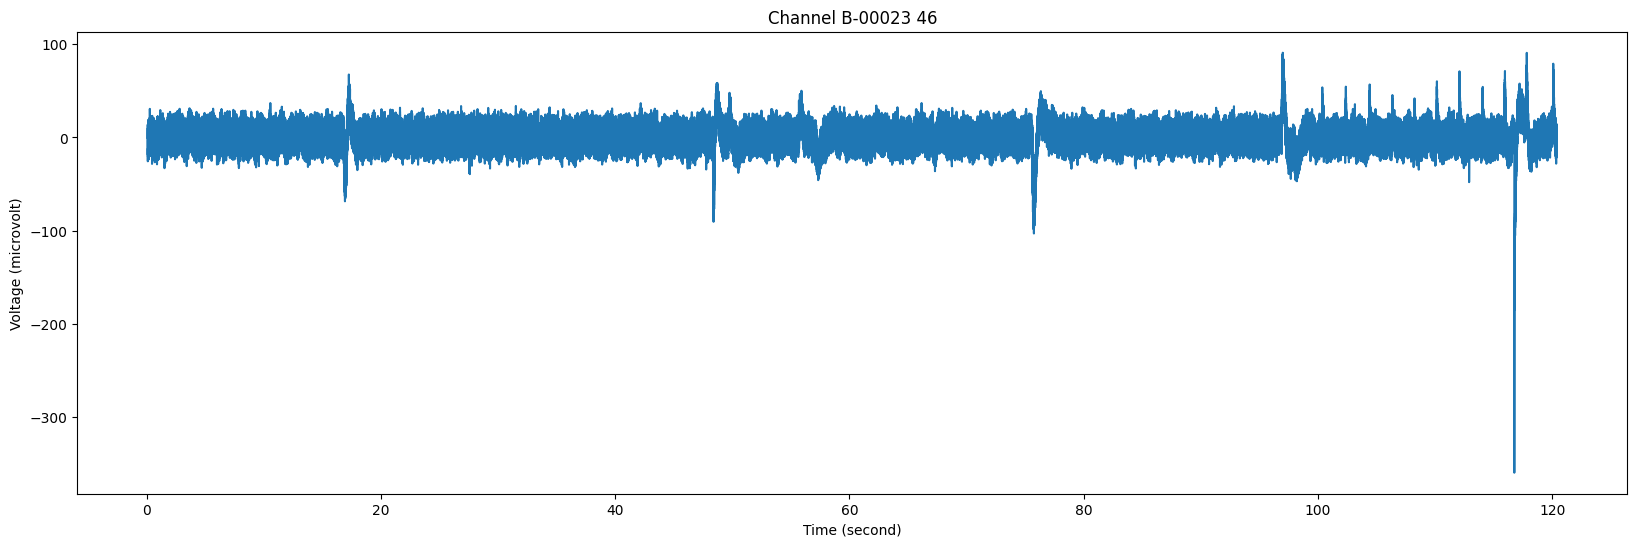

In [12]:
# Check the analog stream of the electrode in channel 0
plot_analog_stream_channel(electrode_stream, channel_idx = 2, from_in_s=0, to_in_s=10000)

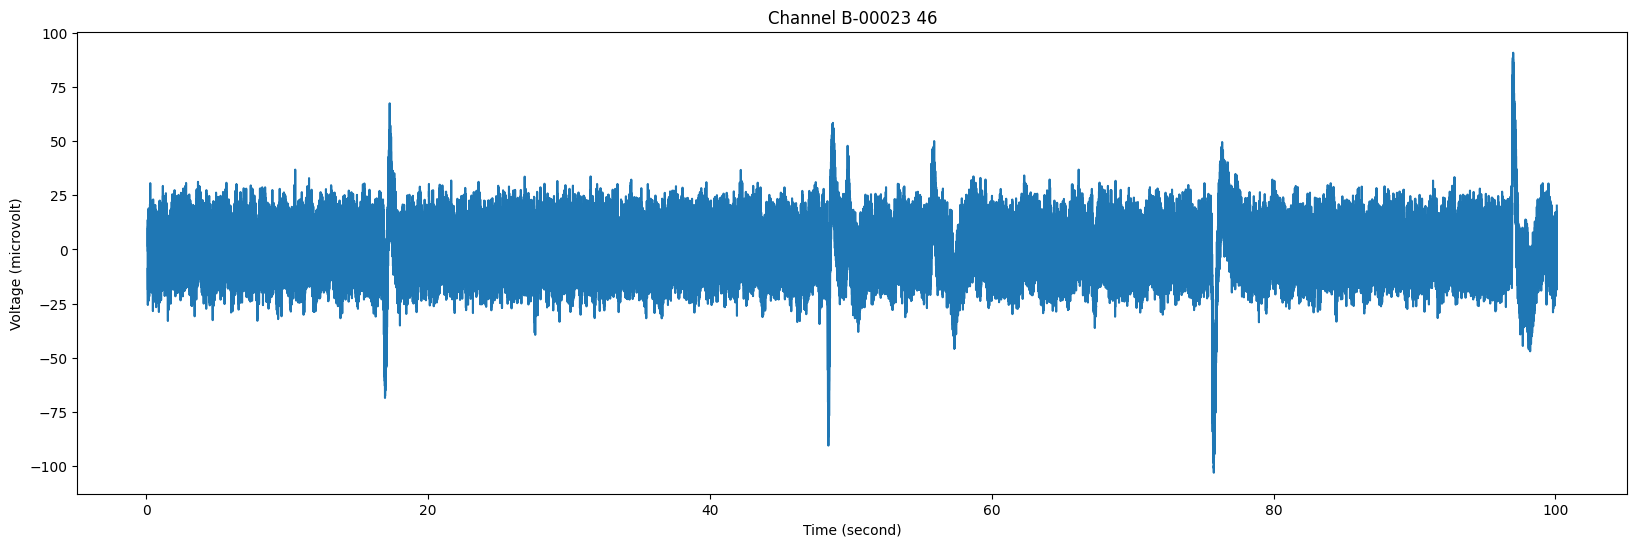

In [13]:
# Check the analog stream of the electrode in channel 0
plot_analog_stream_channel(electrode_stream, channel_idx = 2, from_in_s=0, to_in_s=100)

In [14]:
# Check the bandwidth of the recording to see if
# there have been any filters applied o
channel_id = 2
info = electrode_stream.channel_infos[channel_id].info
print("Bandwidth: %s - %s Hz" % (info['HighPassFilterCutOffFrequency'], info['LowPassFilterCutOffFrequency']))

signal = electrode_stream.get_channel_in_range(channel_id, 0, electrode_stream.channel_data.shape[1])[0]

Bandwidth: -1 - -1 Hz


In [15]:
electrode_stream.channel_infos[0]
fs = (getattr(electrode_stream.channel_infos[0], 'sampling_frequency')) 


<ChannelInfo channel_id=0, row_index=0, sampling_frequency=20000.0 hertz>

In [16]:
type(fs.magnitude)

numpy.float64

In [17]:
# Filter signal
filtered_signal = lowpass_filter(signal, int(fs.magnitude), 50)


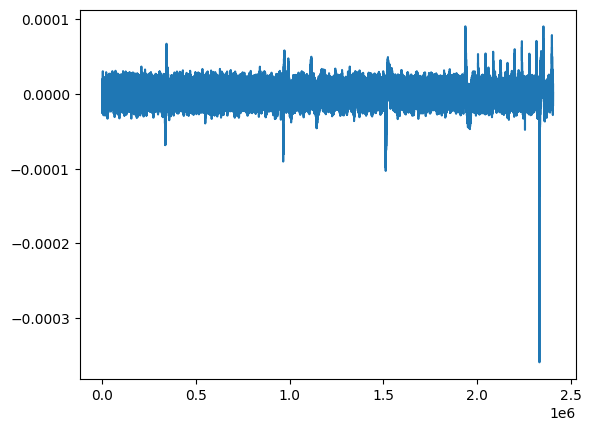

In [18]:
plt.plot(signal)

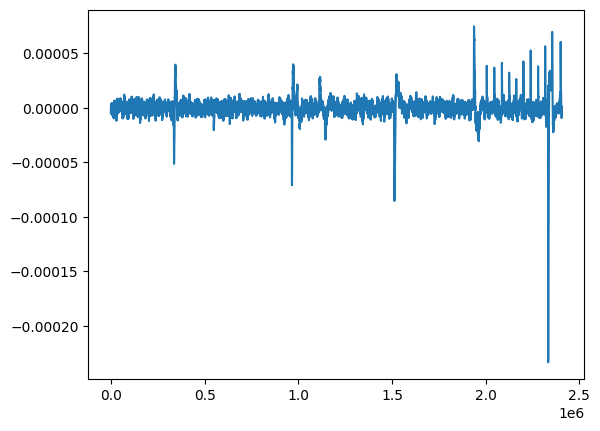

In [19]:
plt.plot(filtered_signal)

In [20]:
# Determine suitable threshold for spike detection
noise_std = np.std(filtered_signal)
noise_mad = np.median(np.absolute(filtered_signal)) / 0.6745
print('Noise Estimate by Standard Deviation: {0:g} V'.format(noise_std))
print('Noise Estimate by MAD Estimator     : {0:g} V'.format(noise_mad))

Noise Estimate by Standard Deviation: 8.97648e-06 V
Noise Estimate by MAD Estimator     : 4.32682e-06 V


In [21]:
spike_threshold = -3.75 * noise_mad # roughly -30 µV

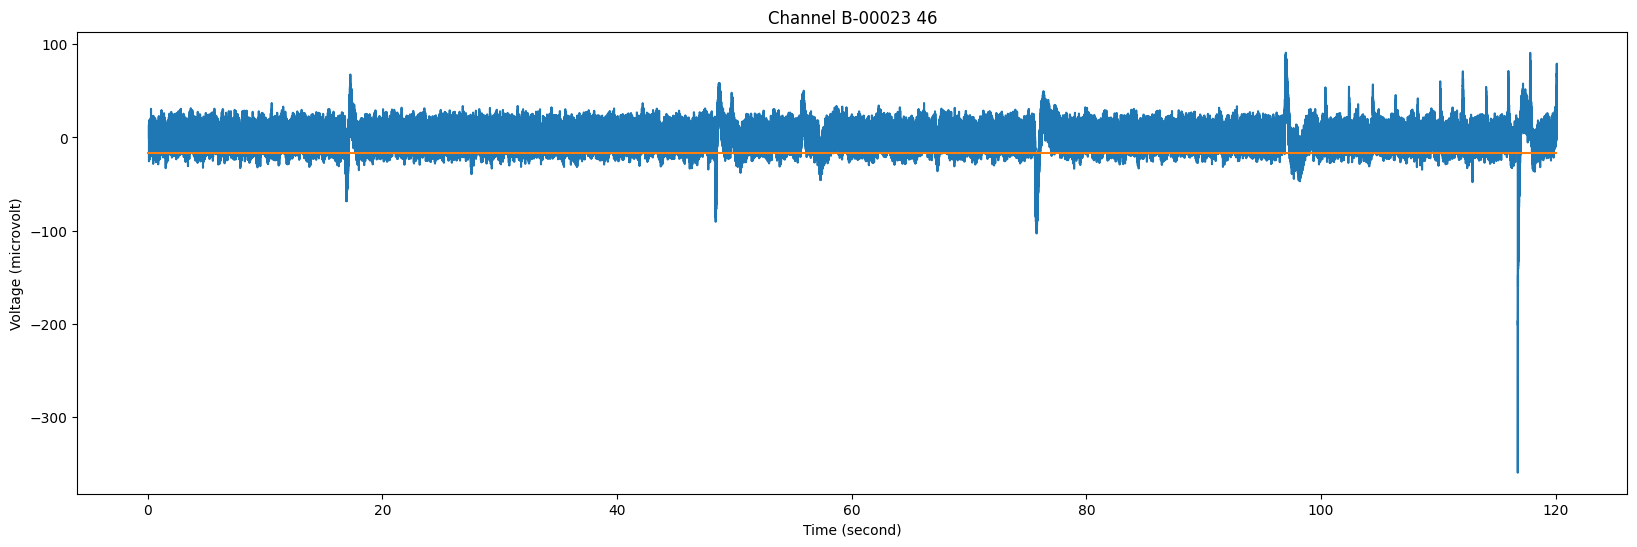

In [22]:
# Plot the data with the spike threshold
plot_analog_stream_channel(electrode_stream, 2, from_in_s=0, to_in_s=120, show=False)

plt.plot([0, 120], [spike_threshold*1e6, spike_threshold*1e6]) # converts the threshold to µV for plotting
plt.show()

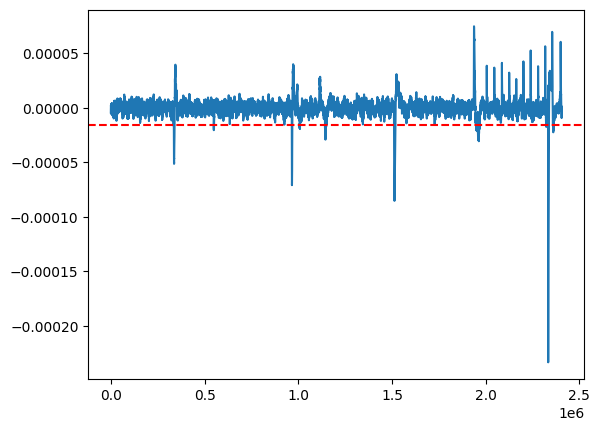

In [23]:
plt.plot(filtered_signal)
# Adding a horizontal line at y=5
plt.axhline(y=spike_threshold, color='r', linestyle='--', label='threshold')



In [39]:
fs = int(electrode_stream.channel_infos[channel_id].sampling_frequency.magnitude)
crossings = detect_threshold_crossings(filtered_signal, fs, spike_threshold, 0.003) # dead time of 3 ms
spks = align_to_minimum(filtered_signal, fs, crossings, 0.002) # search range 2 ms

c:\Users\Ines\anaconda3\envs\scilife-env\Lib\site-packages\McsPy\McsData.py:534: DeprecationWarning: Calling the getitem method from a UnitRegistry will be removed in future versions of pint.
use `parse_expression` method or use the registry as a callable.


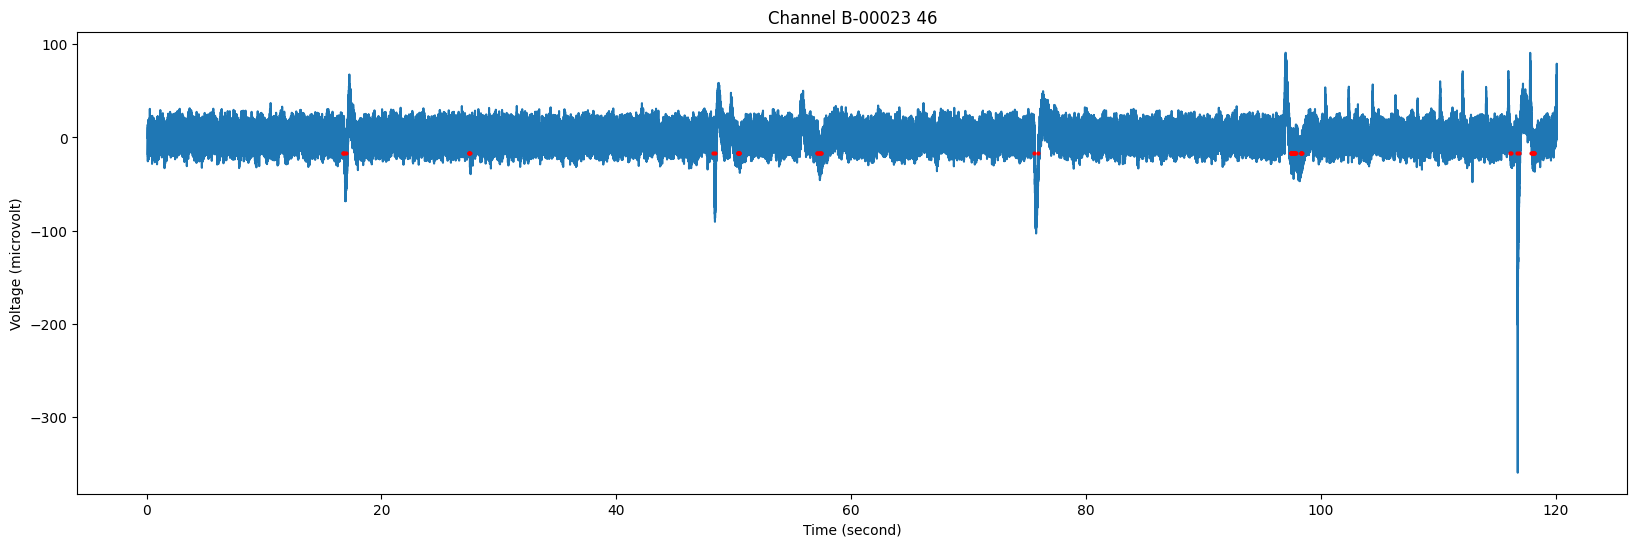

In [40]:
timestamps = spks / fs
range_in_s = (0, 120)
spikes_in_range = timestamps[(timestamps >= range_in_s[0]) & (timestamps <= range_in_s[1])]

plot_analog_stream_channel(electrode_stream, 2, from_in_s=range_in_s[0], to_in_s=range_in_s[1], show=False)
_ = plt.plot(spikes_in_range, [spike_threshold*1e6]*spikes_in_range.shape[0], 'ro', ms=2)
plt.show()

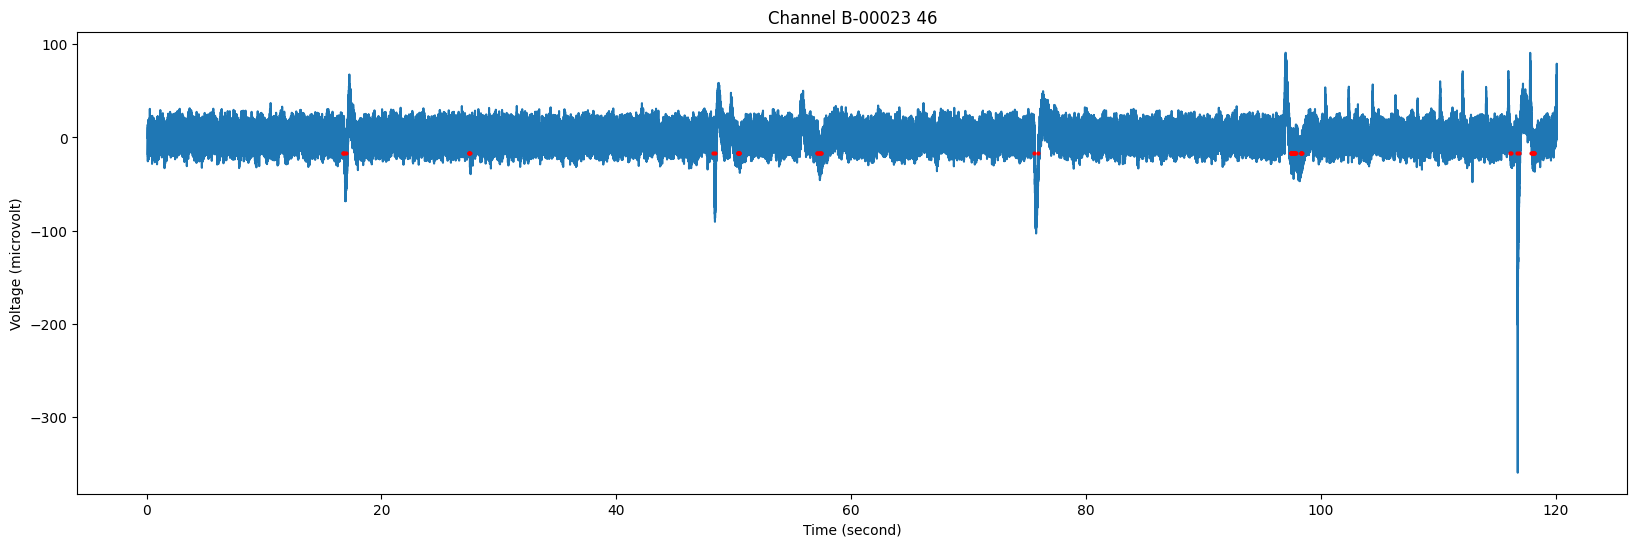

In [41]:

plot_analog_stream_channel(electrode_stream, channel_idx = 2, from_in_s=0, to_in_s=120, show=False)
plt.plot(spikes_in_range, [spike_threshold*1e6]*spikes_in_range.shape[0], 'ro', ms=2)
plt.show()

Text(0.5, 0, 'Time (s)')

Text(0, 0.5, 'Voltage (V)')

Text(0.5, 1.0, 'Detected Spikes')

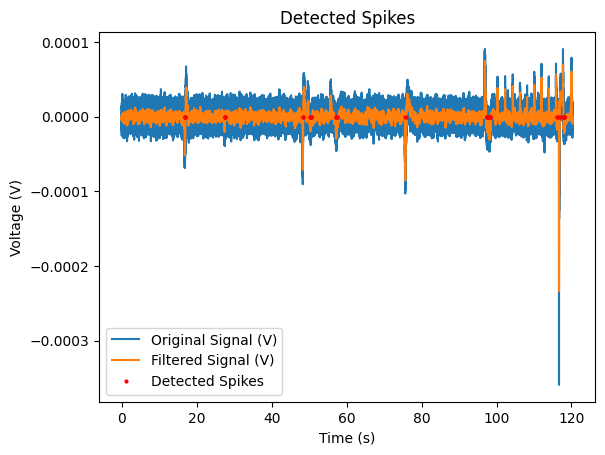

In [42]:

duration = electrode_stream.channel_data.shape[1]/fs
t = np.arange(0, duration, 1/fs)
plt.plot(t,signal, label = "Original Signal (V)")

plt.plot(t,filtered_signal, label='Filtered Signal (V)')

plt.plot(spikes_in_range, [0]*spikes_in_range.shape[0], 'ro', ms=2, label = "Detected Spikes")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Detected Spikes")
plt.legend()



plt.show()

Text(0.5, 1.0, 'Output raster')

Text(0.5, 0, 'Time (s)')

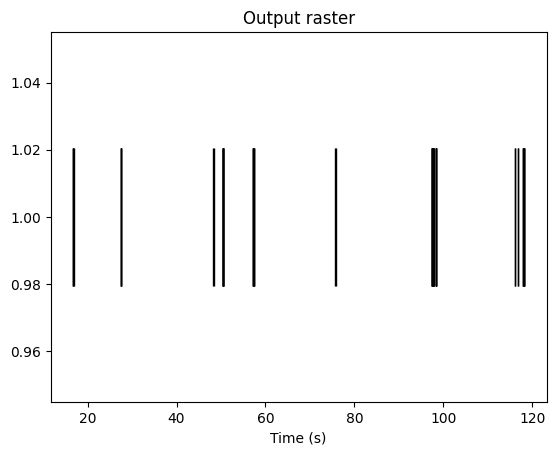

In [47]:
# plot spike train
plt.plot(spikes_in_range, np.ones_like(spikes_in_range), '|', markersize=100, color='black')
plt.title('Output raster')
plt.xlabel('Time (s)')


In [48]:
pre = 0.001 # 1 ms
post= 0.002 # 2 ms
cutouts = extract_waveforms(filtered_signal, fs, spks, pre, post)
print("Cutout array shape: " + str(cutouts.shape)) # number of spikes x number of samples

Cutout array shape: (60, 60)


Crosscorrelations 

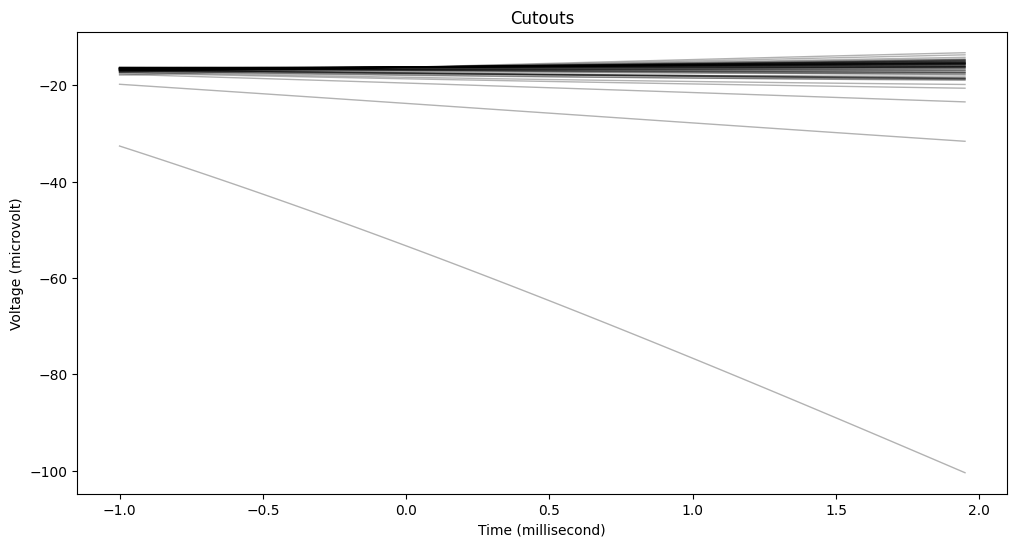

In [49]:
plot_waveforms(cutouts, fs, pre, post, n = 480)


In [34]:
len(cutouts)

60

Analysis with PCA

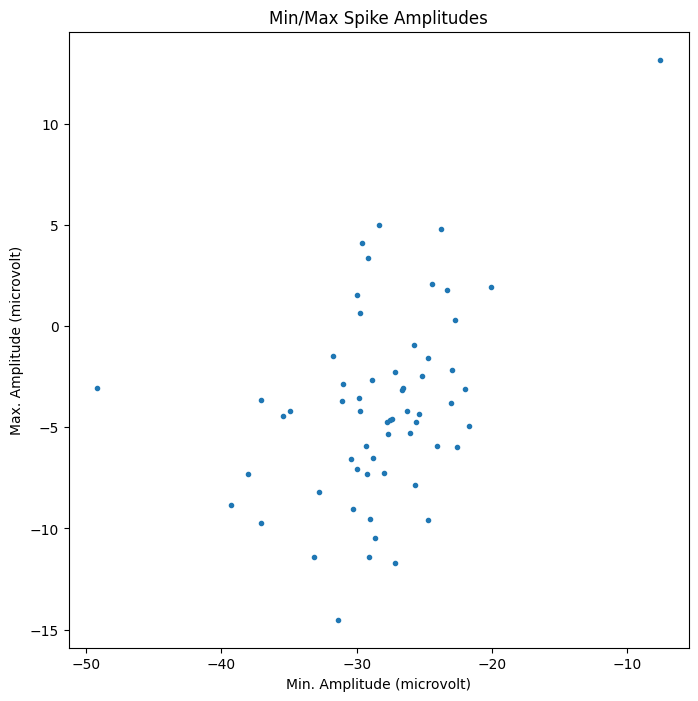

In [35]:
min_amplitude = np.amin(cutouts, axis=1)
max_amplitude = np.amax(cutouts, axis=1)

_ = plt.figure(figsize=(8,8))
_ = plt.plot(min_amplitude*1e6, max_amplitude*1e6,'.')
_ = plt.xlabel('Min. Amplitude (%s)' % ureg.uV)
_ = plt.ylabel('Max. Amplitude (%s)' % ureg.uV)
_ = plt.title('Min/Max Spike Amplitudes')

plt.show()

In [36]:
scaler = StandardScaler()
scaled_cutouts = scaler.fit_transform(cutouts)

pca = PCA()
pca.fit(scaled_cutouts)
print(pca.explained_variance_ratio_)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

[4.02705334e-01 1.49027759e-01 8.03044870e-02 6.19002623e-02
 4.48050924e-02 3.92902421e-02 3.03438141e-02 2.61602925e-02
 2.34447395e-02 2.03189917e-02 1.61314863e-02 1.36002912e-02
 1.24634169e-02 1.14961161e-02 1.07321138e-02 8.91851455e-03
 7.55623112e-03 6.43719503e-03 5.56614276e-03 4.63481687e-03
 4.14127142e-03 3.36863532e-03 3.13397810e-03 2.95565659e-03
 1.90078565e-03 1.54753822e-03 1.26678060e-03 1.06115108e-03
 9.75483704e-04 6.41029833e-04 5.36422543e-04 5.03239732e-04
 4.11688063e-04 3.28715090e-04 3.08468361e-04 2.39216274e-04
 1.88642163e-04 1.50685551e-04 1.19188195e-04 8.55850404e-05
 6.43087208e-05 4.53932627e-05 4.36872794e-05 3.04011365e-05
 2.74930624e-05 2.34032870e-05 1.50541846e-05 1.37014424e-05
 1.02320672e-05 6.93789400e-06 6.03353178e-06 4.61309878e-06
 2.97535622e-06 1.78846242e-06 1.19939771e-06 7.80894932e-07
 3.95790250e-07 9.70007751e-08 3.09080024e-09 6.63509297e-32]


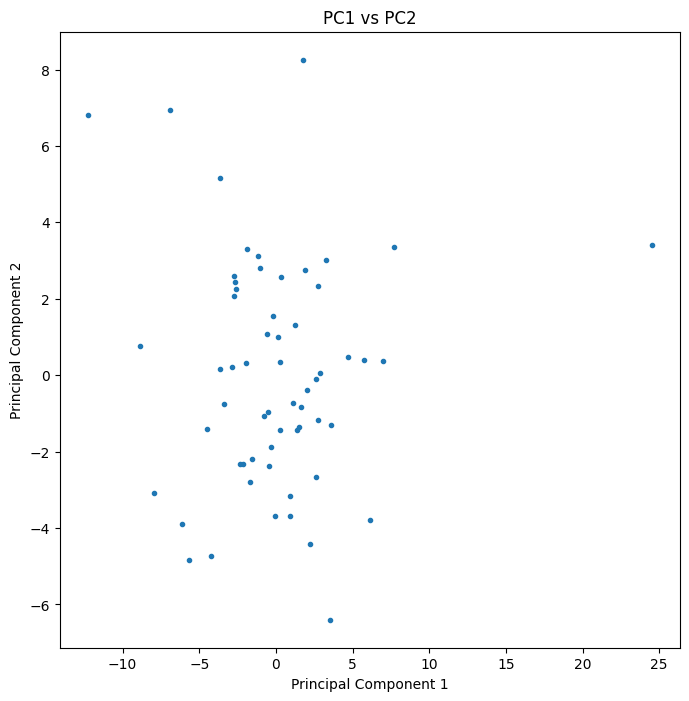

In [37]:
pca.n_components = 2
transformed = pca.fit_transform(scaled_cutouts)

_ = plt.figure(figsize=(8,8))
_ = plt.plot(transformed[:,0], transformed[:,1],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 2')
_ = plt.title('PC1 vs PC2')

plt.show()

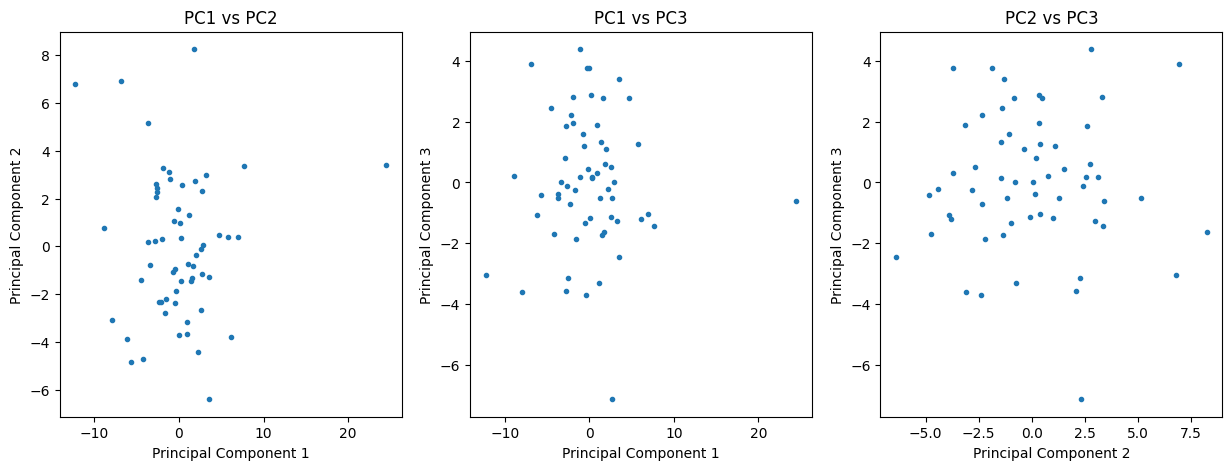

In [38]:
pca.n_components = 3
transformed_3d = pca.fit_transform(scaled_cutouts)

_ = plt.figure(figsize=(15,5))
_ = plt.subplot(1, 3, 1)
_ = plt.plot(transformed_3d[:,0], transformed_3d[:,1],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 2')
_ = plt.title('PC1 vs PC2')
_ = plt.subplot(1, 3, 2)
_ = plt.plot(transformed_3d[:,0], transformed_3d[:,2],'.')
_ = plt.xlabel('Principal Component 1')
_ = plt.ylabel('Principal Component 3')
_ = plt.title('PC1 vs PC3')
_ = plt.subplot(1, 3, 3)
_ = plt.plot(transformed_3d[:,1], transformed_3d[:,2],'.')
_ = plt.xlabel('Principal Component 2')
_ = plt.ylabel('Principal Component 3')
_ = plt.title('PC2 vs PC3')
plt.show()

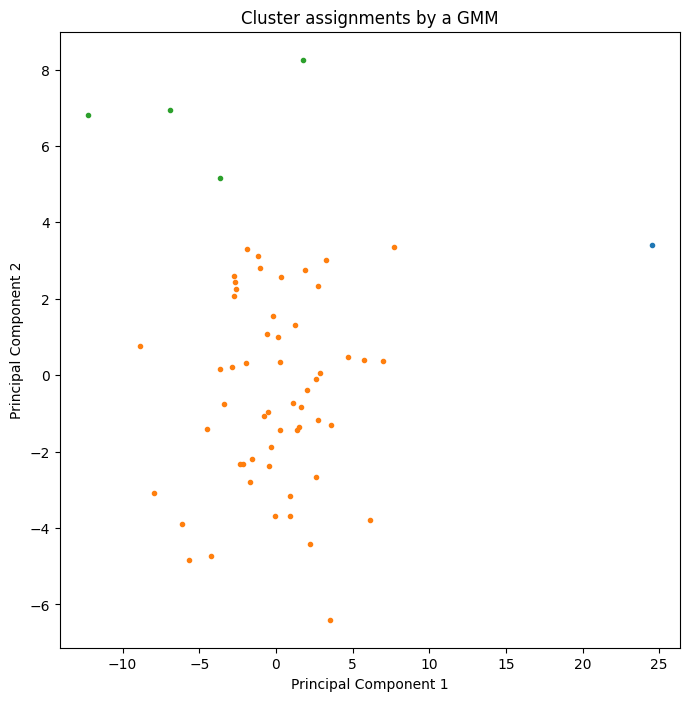

In [41]:
# Clustering
n_components = 3
gmm = GaussianMixture(n_components=n_components, n_init=10)
labels = gmm.fit_predict(transformed)

_ = plt.figure(figsize=(8,8))
for i in range(n_components):
    idx = labels == i
    _ = plt.plot(transformed[idx,0], transformed[idx,1],'.')
    _ = plt.title('Cluster assignments by a GMM')
    _ = plt.xlabel('Principal Component 1')
    _ = plt.ylabel('Principal Component 2')
    _ = plt.axis('tight')
plt.show()

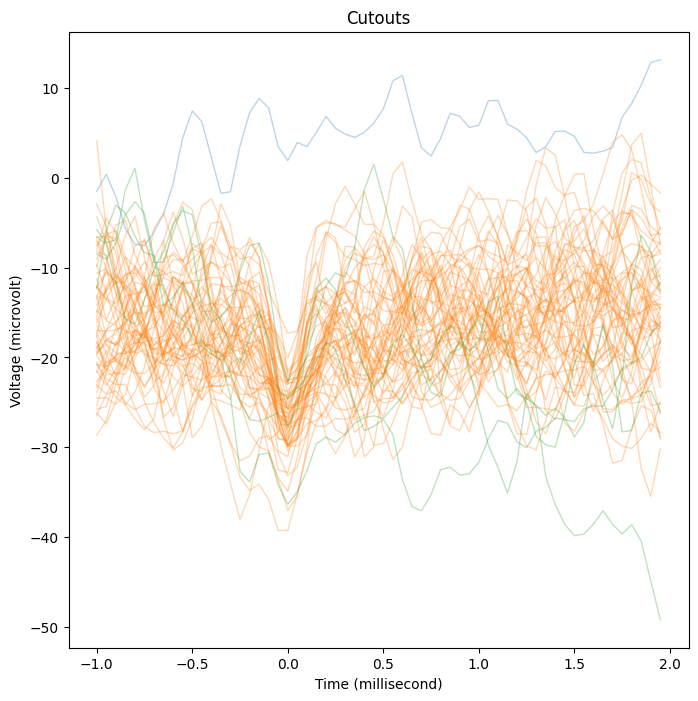

In [44]:
_ = plt.figure(figsize=(8,8))
for i in range(n_components):
    idx = labels == i
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i]
    plot_waveforms(cutouts[idx,:], fs, pre, post, n=100, color=color, show=False)
plt.show()

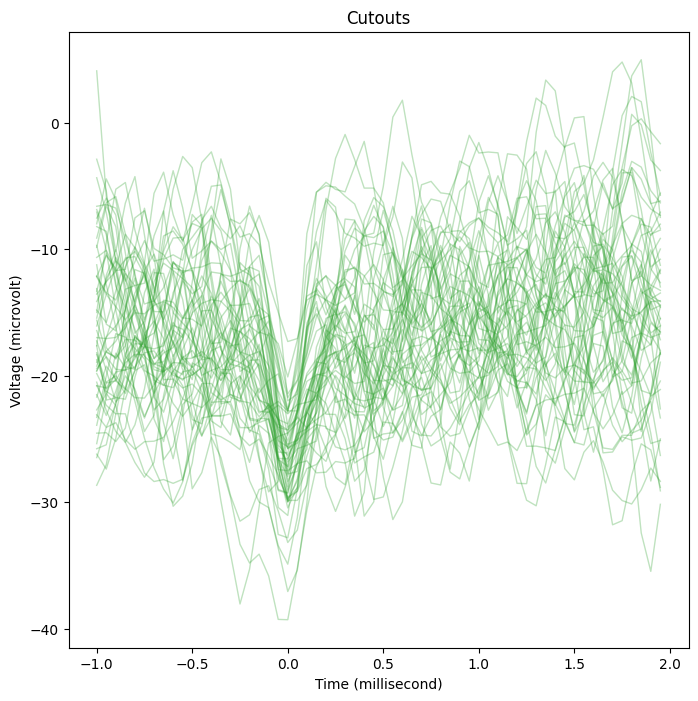

In [43]:
_ = plt.figure(figsize=(8,8))

idx = labels == 1
color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i]
plot_waveforms(cutouts[idx,:], fs, pre, post, n = 200, color=color, show=False)
plt.show()